# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ShamKottish/FlyRankML/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
%pip -q install duckdb huggingface_hub scikit-learn

import os
import json
import getpass
from pathlib import Path

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

# ------------------------------------------------------------
# Hugging Face authentication
# ------------------------------------------------------------

HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass

HF_TOKEN = HF_TOKEN or getpass.getpass(
    "Paste your Hugging Face READ token: "
)

con = duckdb.connect()

con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

FACT_MAR = (
    f"read_parquet('{REL}/"
    "fact_content_daily_performance/month=2026-03/*.parquet')"
)

FACT_APR = (
    f"read_parquet('{REL}/"
    "fact_content_daily_performance/month=2026-04/*.parquet')"
)

OUTPUT_DIR = Path("work/outputs")
FIGURE_DIR = Path("work/figures")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("✓ Connected to FlyRank warehouse")
print("Feature window: March 2026")
print("Outcome window: April 2026")
print("Random seed:", RANDOM_STATE)
print("scikit-learn:", sklearn.__version__)

Paste your Hugging Face READ token: ··········
✓ Connected to FlyRank warehouse
Feature window: March 2026
Outcome window: April 2026
Random seed: 42
scikit-learn: 1.6.1


In [2]:
# ============================================================
# 1. BUILD MARCH FEATURE TABLE
# ============================================================

march = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS feature_impressions,
        SUM(gsc_clicks) AS feature_clicks,

        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN 100.0 * SUM(gsc_clicks)
                 / SUM(gsc_impressions)
        END AS feature_ctr,

        SUM(
            CASE
                WHEN gsc_avg_position > 0
                     AND gsc_impressions > 0
                THEN gsc_avg_position * gsc_impressions
                ELSE 0
            END
        )
        /
        NULLIF(
            SUM(
                CASE
                    WHEN gsc_avg_position > 0
                         AND gsc_impressions > 0
                    THEN gsc_impressions
                    ELSE 0
                END
            ),
            0
        ) AS feature_avg_position,

        STDDEV_SAMP(
            CASE
                WHEN gsc_avg_position > 0
                     AND gsc_impressions > 0
                THEN gsc_avg_position
            END
        ) AS feature_position_std,

        COUNT(
            DISTINCT CASE
                WHEN gsc_impressions > 0
                THEN report_date
            END
        ) AS feature_active_days

    FROM {FACT_MAR}

    GROUP BY
        client_hash_id,
        content_hash_id

    HAVING SUM(gsc_impressions) >= 500
""").df()

march["feature_position_std"] = (
    march["feature_position_std"].fillna(0)
)

march = march[
    march["feature_avg_position"].notna()
].copy()


# ============================================================
# 2. BUILD APRIL OUTCOME TABLE
# ============================================================

april = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS outcome_impressions,
        SUM(gsc_clicks) AS outcome_clicks,

        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN 100.0 * SUM(gsc_clicks)
                 / SUM(gsc_impressions)
        END AS outcome_ctr,

        SUM(
            CASE
                WHEN gsc_avg_position > 0
                     AND gsc_impressions > 0
                THEN gsc_avg_position * gsc_impressions
                ELSE 0
            END
        )
        /
        NULLIF(
            SUM(
                CASE
                    WHEN gsc_avg_position > 0
                         AND gsc_impressions > 0
                    THEN gsc_impressions
                    ELSE 0
                END
            ),
            0
        ) AS outcome_avg_position

    FROM {FACT_APR}

    GROUP BY
        client_hash_id,
        content_hash_id

    HAVING SUM(gsc_impressions) >= 500
""").df()

april = april[
    april["outcome_avg_position"].notna()
].copy()


def position_band(position):
    if position <= 3:
        return "top_3"
    elif position <= 10:
        return "page_1"
    elif position <= 20:
        return "striking"
    elif position <= 50:
        return "page_3_5"
    return "deep"


# Position-adjusted April outcome
april["outcome_position_band"] = (
    april["outcome_avg_position"].apply(position_band)
)

april["outcome_band_median_ctr"] = (
    april
    .groupby("outcome_position_band")["outcome_ctr"]
    .transform("median")
)

april["outcome_ctr_gap_pp"] = (
    april["outcome_band_median_ctr"]
    - april["outcome_ctr"]
)

april["opportunity_proxy"] = (
    april["outcome_ctr_gap_pp"] > 0.10
).astype(int)


# ============================================================
# 3. JOIN MARCH FEATURES TO APRIL OUTCOME
# ============================================================

model_df = march.merge(
    april[
        [
            "client_hash_id",
            "content_hash_id",
            "outcome_impressions",
            "outcome_ctr",
            "outcome_avg_position",
            "outcome_ctr_gap_pp",
            "opportunity_proxy",
        ]
    ],
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

model_df["log_impressions"] = np.log1p(
    model_df["feature_impressions"]
)

model_df["log_clicks"] = np.log1p(
    model_df["feature_clicks"]
)

FEATURES = [
    "log_impressions",
    "log_clicks",
    "feature_ctr",
    "feature_avg_position",
    "feature_position_std",
    "feature_active_days",
]

TARGET = "opportunity_proxy"


# ============================================================
# 4. GROUPED CLIENT HOLDOUT
# ============================================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    gss.split(
        model_df,
        model_df[TARGET],
        groups=model_df["client_hash_id"]
    )
)

train_df = model_df.iloc[train_idx].copy()
test_df = model_df.iloc[test_idx].copy()

assert set(train_df["client_hash_id"]).isdisjoint(
    set(test_df["client_hash_id"])
)


# ============================================================
# 5. BASELINE
# ============================================================

train_df["feature_position_band"] = (
    train_df["feature_avg_position"].apply(position_band)
)

test_df["feature_position_band"] = (
    test_df["feature_avg_position"].apply(position_band)
)

train_band_medians = (
    train_df
    .groupby("feature_position_band")["feature_ctr"]
    .median()
    .to_dict()
)

fallback_ctr = train_df["feature_ctr"].median()

test_df["peer_median_ctr"] = (
    test_df["feature_position_band"]
    .map(train_band_medians)
    .fillna(fallback_ctr)
)

test_df["baseline_ctr_gap_pp"] = (
    test_df["peer_median_ctr"]
    - test_df["feature_ctr"]
)

test_df["baseline_score"] = (
    test_df["baseline_ctr_gap_pp"].clip(lower=0)
    * np.log1p(test_df["feature_impressions"])
)


# ============================================================
# 6. RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(
    train_df[FEATURES],
    train_df[TARGET]
)

test_df["model_score"] = rf.predict_proba(
    test_df[FEATURES]
)[:, 1]


# ============================================================
# 7. METRICS
# ============================================================

def precision_at_k(y_true, scores, k):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    k = min(k, len(y_true))
    order = np.argsort(-scores)

    return y_true[order[:k]].mean()


def evaluate(name, scores):
    return {
        "method": name,
        "precision@20": precision_at_k(
            test_df[TARGET], scores, 20
        ),
        "precision@50": precision_at_k(
            test_df[TARGET], scores, 50
        ),
        "average_precision": average_precision_score(
            test_df[TARGET], scores
        ),
        "roc_auc": roc_auc_score(
            test_df[TARGET], scores
        ),
    }


BASE_RATE = test_df[TARGET].mean()

results = [
    {
        "method": "base_rate",
        "precision@20": BASE_RATE,
        "precision@50": BASE_RATE,
        "average_precision": BASE_RATE,
        "roc_auc": 0.5,
    },
    evaluate(
        "transparent_baseline",
        test_df["baseline_score"]
    ),
    evaluate(
        "random_forest",
        test_df["model_score"]
    ),
]

results_df = pd.DataFrame(results)

metric_cols = [
    "precision@20",
    "precision@50",
    "average_precision",
    "roc_auc",
]

results_df[metric_cols] = (
    results_df[metric_cols].round(3)
)

print(f"Modeling rows: {len(model_df):,}")
print(f"Training clients: {train_df['client_hash_id'].nunique()}")
print(f"Held-out clients: {test_df['client_hash_id'].nunique()}")
print(f"Held-out base rate: {BASE_RATE:.3f}")

display(results_df)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Modeling rows: 51,496
Training clients: 25
Held-out clients: 9
Held-out base rate: 0.215


,method,precision@20,precision@50,average_precision,roc_auc
0,base_rate,0.215,0.215,0.215,0.500
1,transparent_baseline,0.850,0.880,0.555,0.795
2,random_forest,0.850,0.880,0.610,0.864



## Abstract

This study asks whether observed search-performance signals can help prioritize content pages for CTR-focused human review before an editor spends time inspecting them. I use pseudonymized FlyRank warehouse data, with March 2026 as the feature period and April 2026 as a later outcome period, while excluding client-identifying information and future outcome fields from the model. A Random Forest ranks pages using March impressions, clicks, CTR, average position, position volatility, and active search days, and is evaluated on clients completely held out from training against a transparent position-adjusted CTR baseline. On the held-out clients, both the Random Forest and transparent baseline achieved a Precision@50 of **0.880**, substantially above the **0.215** opportunity base rate, while the Random Forest showed stronger overall ranking performance with an Average Precision of **0.610 versus 0.555** and ROC-AUC of **0.864 versus 0.795**. The results support using the system as directional decision-support for prioritizing human review, while also showing that the simpler transparent baseline is sufficient when the operational focus is only the very top of the ranked queue.

## 1. Question

*The research question and the decision it supports.*


Among content pages with enough observed search exposure, which pages can be ranked as the strongest candidates for CTR-focused human review using only information available before the later evaluation period?

The unit of analysis is one pseudonymized content item belonging to one pseudonymized client. The output is an opportunity score and ranked review queue.

The decision this work supports is **which pages an SEO specialist or content editor should inspect first when review capacity is limited**.

A reviewer may inspect the title, meta description, SERP presentation, search-intent alignment, and recent ranking movement before deciding whether any edit is justified.

A false positive wastes reviewer time and could encourage an unnecessary edit. A false negative means a potentially useful review opportunity is ranked too low.

Data and machine learning may help because CTR opportunity depends on several interacting signals, including ranking position, impression volume, existing CTR, and position stability, rather than one universal threshold.

In [3]:
question_summary = {
    "unit_of_analysis": "one pseudonymized client-content item",
    "output": "ranked CTR review opportunity score",
    "decision": "which pages should be reviewed first",
    "human_actor": "SEO specialist or content editor",
    "feature_period": "March 2026",
    "outcome_period": "April 2026",
}

for key, value in question_summary.items():
    print(f"{key}: {value}")

assert len(model_df) > 0

print(f"\nEligible modeling rows: {len(model_df):,}")

unit_of_analysis: one pseudonymized client-content item
output: ranked CTR review opportunity score
decision: which pages should be reviewed first
human_actor: SEO specialist or content editor
feature_period: March 2026
outcome_period: April 2026

Eligible modeling rows: 51,496


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

This capstone uses the approved pseudonymized FlyRank warehouse release and the `fact_content_daily_performance` table.

I use two non-overlapping calendar windows:

- **Feature window:** March 1–31, 2026
- **Outcome window:** April 1–30, 2026

March measurements are aggregated to one row per pseudonymized client-content pair. Pages must have at least 500 March impressions and measurable search position to enter the feature population.

April is used only to construct the later evaluation proxy. For the proxy to be measured with reasonable evidence, the page must also have at least 500 April impressions and measurable position.

The model uses only observed March search-performance information. Raw client names, domains, URLs, titles, private queries, product decision flags, April measurements, and pseudonymous IDs are excluded as predictive features. The IDs remain only for joins and grouped client validation.

I intentionally do not use the fixed 90-day query table because its window could overlap the April outcome period and create leakage.

In [4]:
data_audit = pd.DataFrame([
    {
        "window": "features",
        "period": "2026-03-01 to 2026-03-31",
        "rows": len(march),
    },
    {
        "window": "outcome",
        "period": "2026-04-01 to 2026-04-30",
        "rows": len(april),
    },
    {
        "window": "joined modeling frame",
        "period": "March features -> April outcome",
        "rows": len(model_df),
    },
])

display(data_audit)

forbidden_features = {
    "client_hash_id",
    "content_hash_id",
    "outcome_impressions",
    "outcome_ctr",
    "outcome_avg_position",
    "outcome_ctr_gap_pp",
    "opportunity_proxy",
}

accidental = sorted(
    forbidden_features.intersection(FEATURES)
)

print("Forbidden fields in FEATURES:", accidental)

assert accidental == []

print("✓ Public-safe feature set confirmed.")

,window,period,rows
0,features,2026-03-01 to 2026-03-31,61924
1,outcome,2026-04-01 to 2026-04-30,62051
2,joined modeling frame,March features -> April outcome,51496


Forbidden fields in FEATURES: []
✓ Public-safe feature set confirmed.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Assumptions
1. March behavior is informative about April opportunity:   I assume that search-performance patterns observed in March 2026 contain useful information for ranking pages that may show a CTR opportunity in April 2026. This does not assume that March performance causes April performance.

2. Pages in similar position bands are reasonably comparable.   Because CTR is strongly related to search position, I compare a page's CTR with pages in the same broad position band rather than applying one CTR threshold to every page.

3. At least 500 impressions provides enough evidence for a useful CTR comparison.   Very low-impression pages can show extreme CTR values from only a few clicks. The 500-impression threshold is therefore used to reduce low-volume noise. It is a practical analysis choice, not a universal SEO rule.

4. The April proxy represents review opportunity, not true content quality.  A page is labeled as an opportunity when its April CTR is more than 0.10 percentage points below the median CTR of pages in the same position band. I assume this is a useful decision-support proxy, but it does not prove that the page is poor or that it needs editing.

5. Client-level holdout is a reasonable test of generalization:  I assume that holding out complete clients gives a more realistic estimate of performance on an unseen client than randomly splitting individual pages.

6. The available search measurements capture enough signal for prioritization
   The model does not observe every factor that can influence CTR, such as exact SERP layout, competitor changes, brand strength, or detailed search intent. I assume the available March signals are still useful enough to test a ranking system.

7. The relationship is observational, not causal. The model may identify pages associated with later CTR underperformance, but I do not assume that changing a title, meta description, or page will cause CTR to improve.

8. The March and April windows are sufficiently separated for this prediction setup: All predictive features end on March 31, 2026, and the outcome begins on April 1, 2026. I assume this separation is appropriate for evaluating a next-period ranking task.

### Features

The final model uses six March-only features:

- `log_impressions` — log-transformed March search impressions;
- `log_clicks` — log-transformed March search clicks;
- `feature_ctr` — measured March CTR;
- `feature_avg_position` — impression-weighted March average search position;
- `feature_position_std` — variation in observed March search position;
- `feature_active_days` — number of March days with at least one search impression.

Traffic totals are log-transformed because search-performance data are strongly right-skewed.

### Outcome proxy

The April outcome is a **position-adjusted CTR opportunity proxy**.

Each April page is compared with the median April CTR of pages in the same broad search-position band. A page receives `opportunity_proxy = 1` when its CTR is more than 0.10 percentage points below its position-band median.

This is a rule-defined proxy for review priority, not a causal or human-labeled statement that the page is defective.

### Transparent baseline

The baseline uses March information only:

`positive March peer CTR gap × log(1 + March impressions)`

This prioritizes visible pages whose CTR is below comparable pages at similar search positions.

### Model

The final learned method is a Random Forest classifier. Its predicted probability is used as a ranking score rather than as an automatic yes/no editing decision.

### Validation

Entire clients are held out using `GroupShuffleSplit`. No client appears in both training and testing. This is stricter than a random page split because it tests whether the learned ranking generalizes to clients the model has never seen.

### Leakage controls

All model inputs end on March 31. The outcome begins April 1. April fields, label-derived fields, product flags, and identifiers are prohibited as model features.

In [5]:
methodology_table = pd.DataFrame({
    "feature": FEATURES,
    "available_before_outcome": [True] * len(FEATURES),
})

display(methodology_table)

train_clients = set(train_df["client_hash_id"])
test_clients = set(test_df["client_hash_id"])

assert train_clients.isdisjoint(test_clients)

FEATURE_END = pd.Timestamp("2026-03-31")
OUTCOME_START = pd.Timestamp("2026-04-01")

assert FEATURE_END < OUTCOME_START

future_leaks = [
    c for c in FEATURES
    if "outcome" in c.lower()
    or "april" in c.lower()
    or "proxy" in c.lower()
]

assert future_leaks == []

print("✓ Client overlap:", 0)
print("✓ Features end before outcome starts")
print("✓ No future/label columns in final feature list")

,feature,available_before_outcome
0,log_impressions,True
1,log_clicks,True
2,feature_ctr,True
3,feature_avg_position,True
4,feature_position_std,True
5,feature_active_days,True


✓ Client overlap: 0
✓ Features end before outcome starts
✓ No future/label columns in final feature list


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*


the model, transparent baseline, and population base rate are evaluated on the same held-out clients and the same April opportunity proxy.

The primary metric is Precision@50 because the practical task is ranking a limited number of pages for review rather than classifying every page perfectly.

After running the table below, the reported paper result should use the exact executed values rather than rounded or remembered results from earlier notebooks.

In [6]:
display(results_df)

baseline_p50 = float(
    results_df.loc[
        results_df["method"] == "transparent_baseline",
        "precision@50"
    ].iloc[0]
)

model_p50 = float(
    results_df.loc[
        results_df["method"] == "random_forest",
        "precision@50"
    ].iloc[0]
)

print("\nREADY-TO-PASTE RESULT:")
print(
    f"On completely held-out clients, the Random Forest "
    f"achieved Precision@50 = {model_p50:.3f}, compared "
    f"with {baseline_p50:.3f} for the transparent baseline "
    f"and a population base rate of {BASE_RATE:.3f}."
)

difference = model_p50 - baseline_p50

print(
    f"Absolute model-vs-baseline difference: "
    f"{difference:+.3f}"
)

,method,precision@20,precision@50,average_precision,roc_auc
0,base_rate,0.215,0.215,0.215,0.500
1,transparent_baseline,0.850,0.880,0.555,0.795
2,random_forest,0.850,0.880,0.610,0.864



READY-TO-PASTE RESULT:
On completely held-out clients, the Random Forest achieved Precision@50 = 0.880, compared with 0.880 for the transparent baseline and a population base rate of 0.215.
Absolute model-vs-baseline difference: +0.000



###main results, details
The Random Forest and transparent baseline were evaluated on the same completely held-out clients and against the same April CTR-opportunity proxy.

The held-out population had an opportunity base rate of **0.215 (21.5%)**.

At the top of the ranked queue, the two methods performed identically:

- **Precision@20:** 0.850 for both the transparent baseline and Random Forest
- **Precision@50:** 0.880 for both the transparent baseline and Random Forest

Therefore, the Random Forest did **not** improve the top-20 or top-50 review precision over the transparent rule.

However, the Random Forest performed better across the broader ranking. Its **Average Precision was 0.610**, compared with **0.555** for the transparent baseline, and its **ROC-AUC was 0.864**, compared with **0.795** for the baseline.

This suggests that the learned model captured additional ranking information across the full held-out population, even though that improvement did not change the quality of the first 20 or 50 recommendations.

For the operational decision of which pages to review first, the transparent baseline therefore remains highly competitive and may be preferable because it achieves the same top-of-queue precision with simpler and more interpretable logic.

These results measure association with the later April opportunity proxy. They do not show that editing a recommended page will cause CTR or traffic to improve.

## 5. Limitations

*What this work cannot claim.*

This work has several important limitations.

First, the target is a **rule-defined opportunity proxy**, not direct evidence that a human editor judged the page to require a change.

Second, the analysis is observational. It does not measure what happens after an editor changes a title, description, or page, so it cannot establish that an intervention causes CTR or traffic to improve.

Third, the evaluation population requires at least 500 April impressions. This future-period requirement is used only to determine where the April proxy can be measured reliably, but it means the reported evaluation applies to pages that remained sufficiently visible in April.

Fourth, the model is validated on a specific March-to-April 2026 historical period. Search behavior, SERP design, competition, seasonality, client mix, and ranking dynamics can change over time.

Fifth, the model does not directly observe search intent or the reason a page receives a particular CTR. Two pages at similar average positions can still face very different search-result environments.

Finally, a model score is not an editing instruction. Every high-ranked recommendation requires human review before any content or technical SEO change is made.

In [7]:
limitations = pd.DataFrame([
    {
        "limit": "Proxy target",
        "implication": "Does not equal human-confirmed editing need"
    },
    {
        "limit": "Observational design",
        "implication": "Cannot establish causal effect of edits"
    },
    {
        "limit": "April volume eligibility",
        "implication": "Evaluation applies to pages measurable in April"
    },
    {
        "limit": "One historical transition",
        "implication": "Future periods may behave differently"
    },
    {
        "limit": "Unobserved SERP / intent context",
        "implication": "CTR differences may have external causes"
    },
    {
        "limit": "Human action required",
        "implication": "Score must not trigger automatic publishing"
    },
])

display(limitations)

,limit,implication
0,Proxy target,Does not equal human-confirmed editing need
1,Observational design,Cannot establish causal effect of edits
2,April volume eligibility,Evaluation applies to pages measurable in April
3,One historical transition,Future periods may behave differently
4,Unobserved SERP / intent context,CTR differences may have external causes
5,Human action required,Score must not trigger automatic publishing


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*


The model output is converted into a review queue rather than an automatic action queue.

Each page receives a model score together with transparent March-based reason codes.

Recommended reviewer actions are:

- **Review title, meta, and intent** when a visible page holds a relatively strong search position but its March CTR is below comparable pages.
- **Review search snippet and query fit** when the main signal is a position-adjusted CTR gap.
- **Monitor ranking before editing** when search position was highly volatile.
- **Manual review only** when the model score is elevated but the transparent evidence does not support a specific editing hypothesis.

Before editing, the reviewer should confirm current ranking behavior, likely search intent, SERP layout, seasonality, and the possible downside of changing a page that may already serve another query well.

The system must never automatically rewrite, publish, delete, redirect, deindex, or change technical SEO settings.

In [8]:
# Train-derived peer CTR references only
train_peer_ctr = (
    train_df
    .groupby("feature_position_band")["feature_ctr"]
    .median()
    .to_dict()
)

test_df["march_peer_ctr"] = (
    test_df["feature_position_band"]
    .map(train_peer_ctr)
    .fillna(train_df["feature_ctr"].median())
)

test_df["march_ctr_gap_pp"] = (
    test_df["march_peer_ctr"]
    - test_df["feature_ctr"]
)


def make_reasons(row):
    reasons = []

    if row["feature_impressions"] >= 3000:
        reasons.append("high_visibility")

    if row["march_ctr_gap_pp"] >= 0.10:
        reasons.append("below_position_peer_ctr")

    if (
        row["feature_avg_position"] <= 20
        and row["march_ctr_gap_pp"] >= 0.10
    ):
        reasons.append("strong_position_ctr_gap")

    if row["feature_position_std"] >= 10:
        reasons.append("position_volatile")

    if not reasons:
        reasons.append("model_priority_only")

    return "; ".join(reasons)


def recommended_action(row):
    if row["feature_position_std"] >= 10:
        return "monitor_position_before_edit"

    if (
        row["feature_avg_position"] <= 20
        and row["march_ctr_gap_pp"] >= 0.10
    ):
        return "review_title_meta_and_intent"

    if row["march_ctr_gap_pp"] >= 0.10:
        return "review_snippet_and_query_fit"

    return "manual_review_only"


test_df["reason_codes"] = test_df.apply(
    make_reasons,
    axis=1
)

test_df["recommended_action"] = test_df.apply(
    recommended_action,
    axis=1
)

ranked_queue = (
    test_df
    .sort_values("model_score", ascending=False)
    .reset_index(drop=True)
)

ranked_queue.insert(
    0,
    "rank",
    np.arange(1, len(ranked_queue) + 1)
)

public_queue = ranked_queue[
    [
        "rank",
        "content_hash_id",
        "model_score",
        "recommended_action",
        "reason_codes",
        "feature_impressions",
        "feature_ctr",
        "feature_avg_position",
        "march_ctr_gap_pp",
        "feature_position_std",
    ]
].copy()

display(public_queue.head(20))

# Confirm that no outcome fields appear in the action queue.
assert not any(
    "outcome" in c.lower()
    or "proxy" in c.lower()
    or "april" in c.lower()
    for c in public_queue.columns
)

print("✓ Recommendation queue contains March information only.")

,rank,content_hash_id,model_score,recommended_action,reason_codes,feature_impressions,feature_ctr,feature_avg_position,march_ctr_gap_pp,feature_position_std
0,1,content_96bcbfd602ef158e,0.917258,review_title_meta_and_intent,high_visibility; below_position_peer_ctr; stro...,15107.0,0.006619,6.456477,0.251879,0.871045
1,2,content_bcc0248af1702d97,0.914736,review_title_meta_and_intent,high_visibility; below_position_peer_ctr; stro...,13369.0,0.022440,5.718827,0.236058,0.820202
2,3,content_3a9aa0258f31b923,0.914406,review_title_meta_and_intent,high_visibility; below_position_peer_ctr; stro...,11978.0,0.041743,5.037986,0.216755,0.693853
3,4,content_4257d1459eb1fdd1,0.913600,review_title_meta_and_intent,high_visibility; below_position_peer_ctr; stro...,20741.0,0.019285,6.671134,0.239213,0.654290
4,5,content_244cb9de873cae3e,0.910967,review_title_meta_and_intent,high_visibility; below_position_peer_ctr; stro...,8875.0,0.022535,6.779155,0.235963,0.649198
5,6,content_5b428f5c6e80ff0b,0.910232,review_title_meta_and_intent,high_visibility; below_position_peer_ctr; stro...,12283.0,0.008141,6.476756,0.250357,1.291340
6,7,content_8b10a46669bfb27a,0.910075,review_title_meta_and_intent,high_visibility; below_position_peer_ctr; stro...,11629.0,0.042996,4.945739,0.215502,0.913722
7,8,content_92d2c3fc8bf462c9,0.909848,review_title_meta_and_intent,high_visibility; below_position_peer_ctr; stro...,8343.0,0.000000,6.171401,0.258498,0.898454
8,9,content_345c8feeab5d080a,0.909349,review_title_meta_and_intent,high_visibility; below_position_peer_ctr; stro...,23418.0,0.004270,4.969980,0.254228,0.558945
9,10,content_074dc8143a0971bc,0.909254,review_title_meta_and_intent,high_visibility; below_position_peer_ctr; stro...,7514.0,0.026617,6.583710,0.231881,0.706620


✓ Recommendation queue contains March information only.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*


The deployed paper uses a small number of figures, each with one clear message:

1. **Model vs baseline at Precision@50** — whether the learned ranking improves over the transparent rule on the same held-out clients.
2. **Held-out permutation importance** — which March variables the model relies on most strongly.
3. **Top-20 recommendation scores** — what the final human-review queue looks like at the top.

Feature importance is interpreted as predictive dependence rather than causality. A feature appearing important does not mean changing that feature will produce a better outcome.

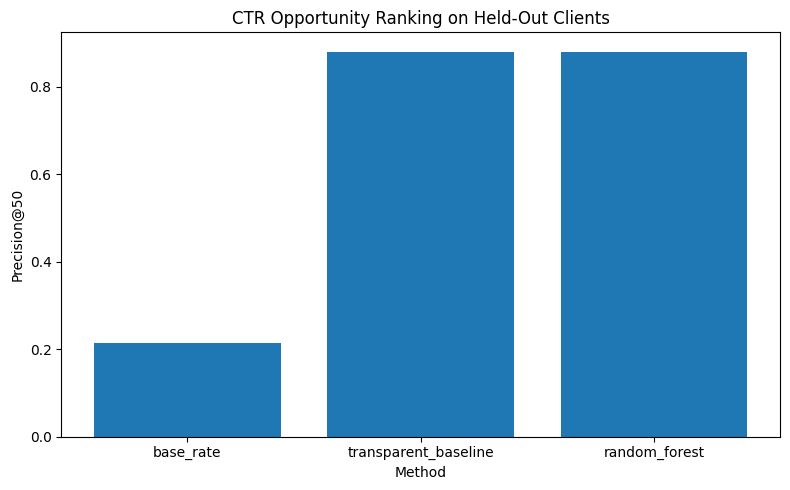

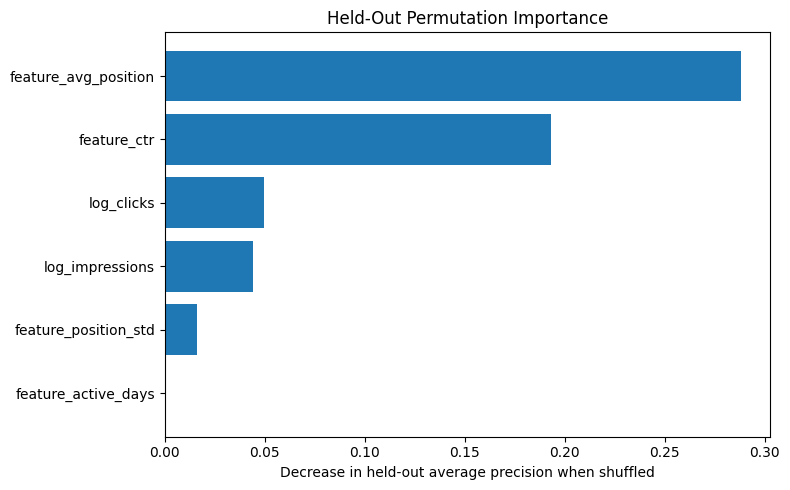

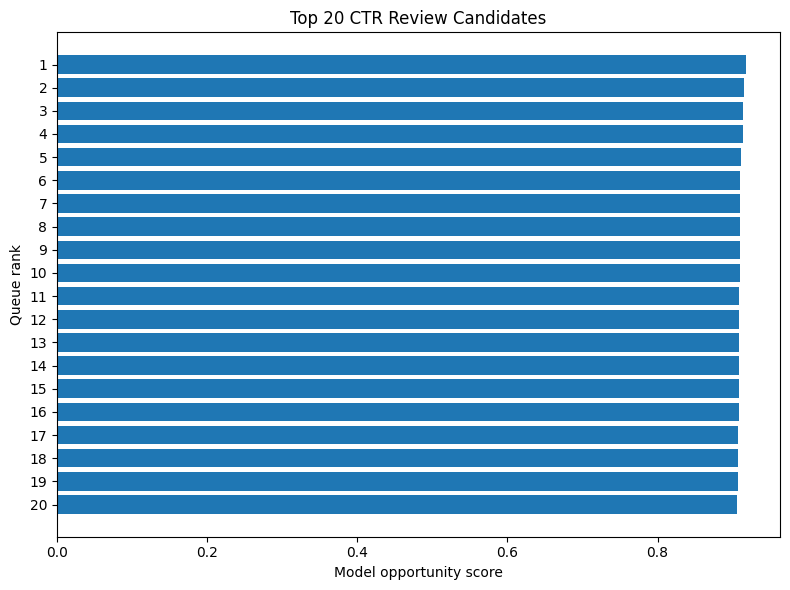

Generated:
- work/figures/capstone_model_vs_baseline.png
- work/figures/capstone_feature_importance.png
- work/figures/capstone_top20_queue.png
- work/outputs/capstone_metrics.json
- work/outputs/capstone_ranked_queue.csv


In [9]:
# ============================================================
# FIGURE 1 — MODEL VS BASELINE
# ============================================================

plot_results = results_df[
    results_df["method"].isin([
        "base_rate",
        "transparent_baseline",
        "random_forest",
    ])
].copy()

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    plot_results["method"],
    plot_results["precision@50"]
)

ax.set_ylabel("Precision@50")
ax.set_xlabel("Method")
ax.set_title(
    "CTR Opportunity Ranking on Held-Out Clients"
)

fig.tight_layout()

RESULT_FIG = FIGURE_DIR / "capstone_model_vs_baseline.png"

fig.savefig(
    RESULT_FIG,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 2 — PERMUTATION IMPORTANCE
# ============================================================

perm = permutation_importance(
    rf,
    test_df[FEATURES],
    test_df[TARGET],
    scoring="average_precision",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature": FEATURES,
    "importance": perm.importances_mean,
}).sort_values(
    "importance",
    ascending=True
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    importance_df["feature"],
    importance_df["importance"]
)

ax.set_xlabel(
    "Decrease in held-out average precision when shuffled"
)

ax.set_title(
    "Held-Out Permutation Importance"
)

fig.tight_layout()

IMPORTANCE_FIG = (
    FIGURE_DIR
    / "capstone_feature_importance.png"
)

fig.savefig(
    IMPORTANCE_FIG,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 3 — TOP 20
# ============================================================

top20 = public_queue.head(20).copy()

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(
    top20["rank"].astype(str),
    top20["model_score"]
)

ax.invert_yaxis()

ax.set_xlabel("Model opportunity score")
ax.set_ylabel("Queue rank")
ax.set_title("Top 20 CTR Review Candidates")

fig.tight_layout()

QUEUE_FIG = (
    FIGURE_DIR
    / "capstone_top20_queue.png"
)

fig.savefig(
    QUEUE_FIG,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# METRICS RECEIPT
# ============================================================

metrics_receipt = {
    "lane": "CTR opportunity scoring",
    "feature_window": "2026-03-01 to 2026-03-31",
    "outcome_window": "2026-04-01 to 2026-04-30",
    "validation": "grouped client holdout",
    "random_state": RANDOM_STATE,
    "modeling_rows": int(len(model_df)),
    "heldout_rows": int(len(test_df)),
    "heldout_clients": int(
        test_df["client_hash_id"].nunique()
    ),
    "base_rate": float(BASE_RATE),
    "baseline_precision_at_50": float(
        baseline_p50
    ),
    "model_precision_at_50": float(
        model_p50
    ),
    "claim_level": "observational decision-support",
}

METRICS_PATH = (
    OUTPUT_DIR / "capstone_metrics.json"
)

with open(METRICS_PATH, "w") as f:
    json.dump(
        metrics_receipt,
        f,
        indent=2
    )

# Optional local queue export.
# This should be regenerated by the notebook, not force-committed.
QUEUE_PATH = OUTPUT_DIR / "capstone_ranked_queue.csv"

public_queue.to_csv(
    QUEUE_PATH,
    index=False
)

print("Generated:")
print("-", RESULT_FIG)
print("-", IMPORTANCE_FIG)
print("-", QUEUE_FIG)
print("-", METRICS_PATH)
print("-", QUEUE_PATH)

## 8. Reproducibility

The complete analysis is contained in `work/notebooks/capstone.ipynb`.

The notebook uses a fixed random seed of `42`. From a fresh runtime, the user must have approved access to the FlyRank internship warehouse and provide a Hugging Face READ token through the notebook's secure prompt or Colab Secrets.

The workflow then:

1. loads March and April daily performance through DuckDB;
2. aggregates one row per pseudonymized client-content item;
3. creates March-only features;
4. constructs the April position-adjusted opportunity proxy;
5. creates a grouped client holdout;
6. trains the transparent baseline and Random Forest;
7. computes the held-out metrics;
8. generates the ranked queue and paper figures.

The numerical receipt is stored in `work/outputs/capstone_metrics.json`, and the paper figures are stored under `work/figures/`.

In [10]:
reproducibility = {
    "random_seed": RANDOM_STATE,
    "python_workflow": "capstone.ipynb",
    "feature_window": "March 2026",
    "outcome_window": "April 2026",
    "validation": "GroupShuffleSplit by client_hash_id",
    "metrics_receipt": str(METRICS_PATH),
}

print(json.dumps(reproducibility, indent=2))

{
  "random_seed": 42,
  "python_workflow": "capstone.ipynb",
  "feature_window": "March 2026",
  "outcome_window": "April 2026",
  "validation": "GroupShuffleSplit by client_hash_id",
  "metrics_receipt": "work/outputs/capstone_metrics.json"
}


## 9. Acknowledgments & data credit

This project was completed as part of the FlyRank ML Internship and was built on the approved pseudonymized FlyRank ML Internship dataset.

Data and program credit: [FlyRank](https://flyrank.ai/).

No raw client names, domains, URLs, page titles, or private search queries are included in this public analysis.

## ML-12 — 5-Minute Demo Outline

### 0:00–0:45 — The problem

Content teams may manage thousands of pages but have limited time to review them. My capstone asks:

**Can observed search-performance signals help identify which pages should be reviewed first for possible CTR opportunities?**

Instead of automatically changing pages, the goal is to create a ranked decision-support queue for SEO specialists and content editors.

### 0:45–1:30 — The data

I used pseudonymized FlyRank warehouse data.

- March 2026 was used as the feature window.
- April 2026 was used as the later outcome window.
- Each row represents one pseudonymized client-content item.
- Pages required at least 500 impressions and measurable search position.

The model does not use client names, URLs, page titles, private queries, product flags, or April outcome information as predictive features.

### 1:30–2:30 — Baseline and model

I first created a transparent baseline that prioritizes visible pages whose CTR is below other pages at similar search positions.

I then trained a Random Forest using six March search signals:

- impressions
- clicks
- CTR
- average position
- position volatility
- active search days

The model's probability is used as a ranking score rather than an automatic editing decision.

### 2:30–3:30 — Honest validation and results

I held out complete clients from training so the final evaluation measured performance on clients the model had never seen.

The opportunity base rate on the held-out population was **21.5%**.

The transparent baseline achieved:

- Precision@20: **0.850**
- Precision@50: **0.880**
- Average Precision: **0.555**
- ROC-AUC: **0.795**

The Random Forest achieved:

- Precision@20: **0.850**
- Precision@50: **0.880**
- Average Precision: **0.610**
- ROC-AUC: **0.864**

The Random Forest therefore did not improve the first 20 or 50 recommendations, but it provided stronger ranking performance across the broader held-out population.

### 3:30–4:30 — Action playbook

The final output is a ranked human-review queue.

Recommendations include reason codes such as:

- high visibility
- below-position-peer CTR
- strong-position CTR gap
- position volatility

A reviewer can then investigate the page's title, meta description, search intent, SERP presentation, and recent ranking movement before deciding whether a change is appropriate.

### 4:30–5:00 — Takeaway

The main lesson was that a more complex ML model is not automatically better for every operational decision.

For the top-50 review queue, the transparent baseline performed just as well as the Random Forest. The Random Forest showed stronger broader ranking discrimination, but the simpler baseline remains highly competitive when interpretability and top-of-queue performance are the priority.

The system provides **observational decision-support**. It does not prove that editing a recommended page will increase CTR or traffic.

## ML-12 — Social Post

I recently completed a machine learning capstone focused on **CTR Opportunity Scoring** using pseudonymized search-performance data from the FlyRank ML Internship.

The challenge was not simply to train a model, but to answer a practical question:

**Which content pages should an SEO or content team review first when their time is limited?**

I built an end-to-end workflow that included:

- data-contract design
- feature engineering
- leakage and privacy checks
- signal auditing
- a transparent rule-based baseline
- Random Forest modeling
- client-level holdout validation
- ranking evaluation using Precision@K
- error analysis
- an explainable human-review action playbook

On completely held-out clients, both the transparent baseline and Random Forest achieved **88% Precision@50**, compared with a **21.5% base rate**.

Interestingly, the Random Forest did not outperform the baseline at the top 20 or top 50 recommendations. However, it achieved stronger overall ranking performance, with Average Precision improving from **0.555 to 0.610** and ROC-AUC from **0.795 to 0.864**.

One of my biggest takeaways was that better machine learning is not always about choosing the most complex model. Sometimes a simple, explainable baseline can perform just as well for the actual operational decision.

The final system is designed as **decision-support for human reviewers**, not as an automatic editing tool or a causal prediction of what will improve search performance.

## ML-12 — Employer-Facing Summary

I built an end-to-end machine learning ranking pipeline using pseudonymized real-world search-performance data to prioritize content pages for CTR-focused human review. I designed time-separated feature and outcome windows, engineered features, created a transparent baseline, trained a Random Forest, tested it on completely held-out clients, audited leakage, evaluated it using ranking metrics, and converted the results into an explainable action queue. The project demonstrated that the Random Forest improved broader ranking discrimination, while the transparent baseline matched its **88% Precision@50**, highlighting my ability to evaluate whether ML complexity actually adds operational value rather than using a model simply because one is available.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
